## ARIMA Forecasting Aircraft Availability

In [15]:
# Load dependencies
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from dateutil.parser import parse
plt.rcParams.update({'figure.figsize': (10,7), 'figure.dpi': 120})


In [10]:
# load data
df = pd.read_csv('status.csv', parse_dates = ['Start Date'], index_col='Start Date')
df.sort_values(by='Start Date', axis=0, ascending=True)
df.head()

,Daily Possessed Hours,Daily MC Hours,Daily MC Acft,Daily MC %
Start Date,,,,
2018-01-01,336.0,288.0,12.00,0.857143
2018-01-02,336.0,288.0,12.00,0.857143
2018-01-03,336.0,248.3,10.35,0.738988
2018-01-04,336.0,280.6,11.69,0.835119
2018-01-05,336.0,244.3,10.18,0.727083


In [3]:
# Quick Analysis

print(df.describe())
print(df.info())


       Daily Possessed Hours  Daily MC Hours  Daily MC Acft   Daily MC %
count            1614.000000     1614.000000    1614.000000  1614.000000
mean              326.862330      242.936741      10.122800     0.743079
std                14.440084       35.326087       1.471766     0.102140
min               264.000000       95.200000       3.970000     0.305128
25%               312.000000      219.000000       9.130000     0.677083
50%               336.000000      244.600000      10.190000     0.750000
75%               336.000000      265.275000      11.050000     0.818080
max               360.000000      336.000000      14.000000     1.000000
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1614 entries, 2018-01-01 to 2022-06-02
Data columns (total 4 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Daily Possessed Hours  1614 non-null   float64
 1   Daily MC Hours         1614 non-null   float64
 2   Daily 

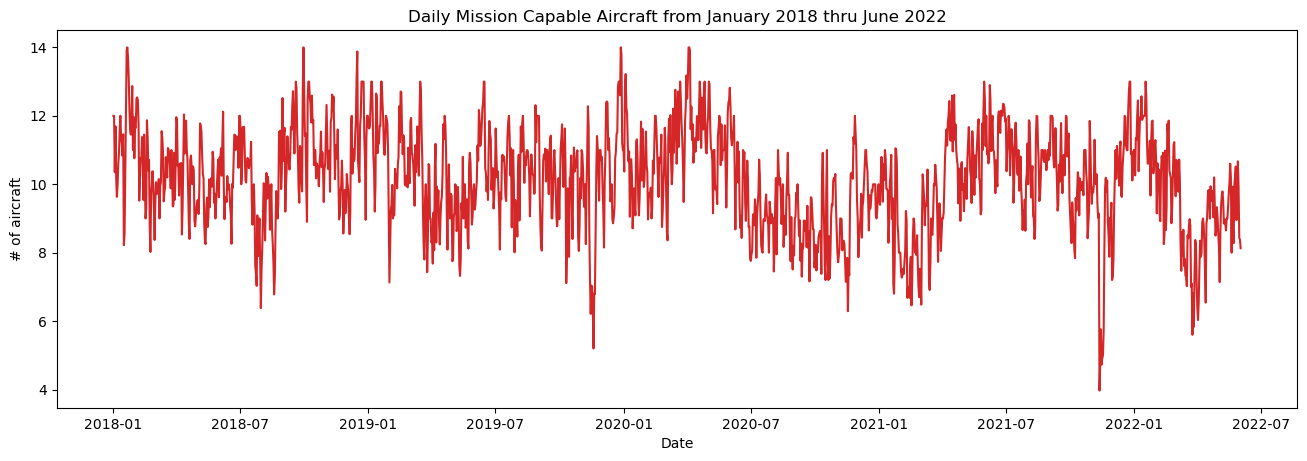

In [4]:
# Draw plot

def plot_df(df, x, y, title = "", xlabel="Date", ylabel="# of aircraft", dpi=100):
    plt.figure(figsize=(16,5), dpi=dpi)
    plt.plot(x, y, color='tab:red')
    plt.gca().set(title=title, xlabel=xlabel, ylabel=ylabel)
    plt.show()
    
plot_df(df, x=df.index, y=df["Daily MC Acft"], title = "Daily Mission Capable Aircraft from January 2018 thru June 2022")

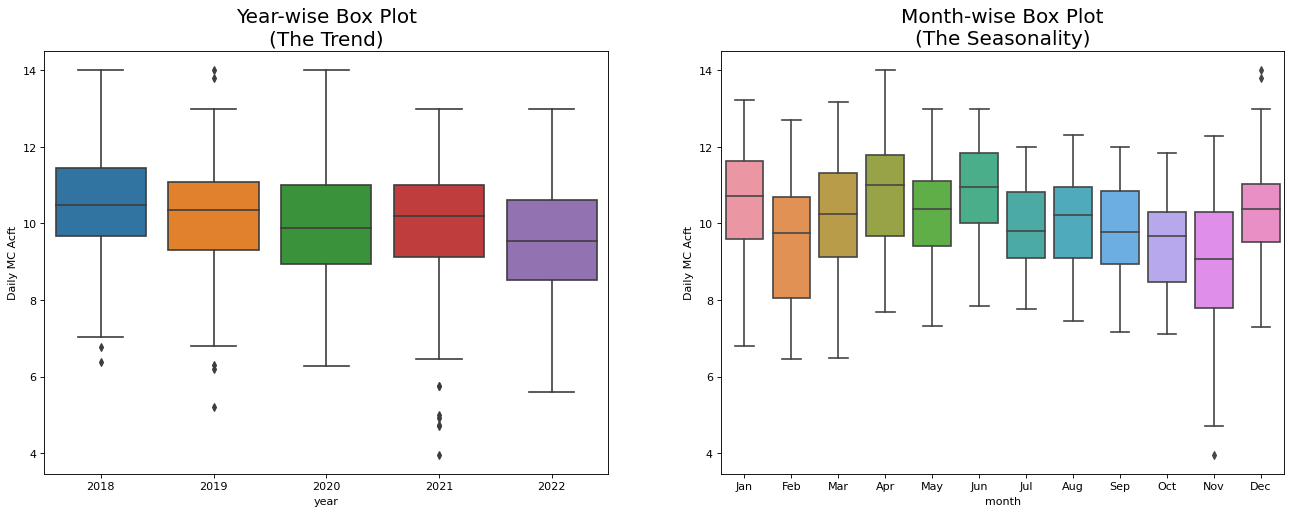

In [30]:
# Boxplot of monthly seasonal data

df['year'] = [d.year for d in df['Start Date']]
df['month'] = [d.strftime('%b') for d in df['Start Date']]
years = df['year'].unique()

# draw plot
fig, axes = plt.subplots(1, 2, figsize=(20,7), dpi=80)
sns.boxplot(x='year', y=df['Daily MC Acft'], data=df, ax=axes[0])
sns.boxplot(x='month', y=df['Daily MC Acft'], data=df.loc[~df.year.isin([2018, 2022]), :])

# set title
axes[0].set_title('Year-wise Box Plot\n(The Trend)', fontsize=18); 
axes[1].set_title('Month-wise Box Plot\n(The Seasonality)', fontsize=18)
plt.show()

The boxplots show the slight downward trend of daily MC aircraft over the years and the annual seasonality. While the average daily MC aircraft is similar throughout the years, we can see that there are high variances.

### Test for stationarity
In order to use the data for forecasting, we must first ensure that the data is stationary -- meaning statistical properties of the data like the mean, variance, and autocorrelation areconstant over time. Stationary series allos for a more reliable forecast. To achieve stationarity, we can test the series of data using a 'Unit Root Tests'. The most common Unit Root Test is the Augmented Dickey Fuller test (ADH Test). If the p-value of the ADH test is less than the significance level of (0.05), reject the null hypothesis of "the time series possesses a unit root and is non-stationary".

In [35]:
# Test for stationarity using ADH Test

from statsmodels.tsa.stattools import adfuller, kpss

result = adfuller(df['Daily MC Acft'], autolag='AIC')
print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1]}')
for key, value in result[4].items():
    print('Critical Values:')
    print(f'  {key}, {value}')
    

ADF Statistic: -5.19722110420254
p-value: 8.907665810897284e-06
Critical Values:
  1%, -3.4344410778805936
Critical Values:
  5%, -2.86334697077965
Critical Values:
  10%, -2.567731995333179


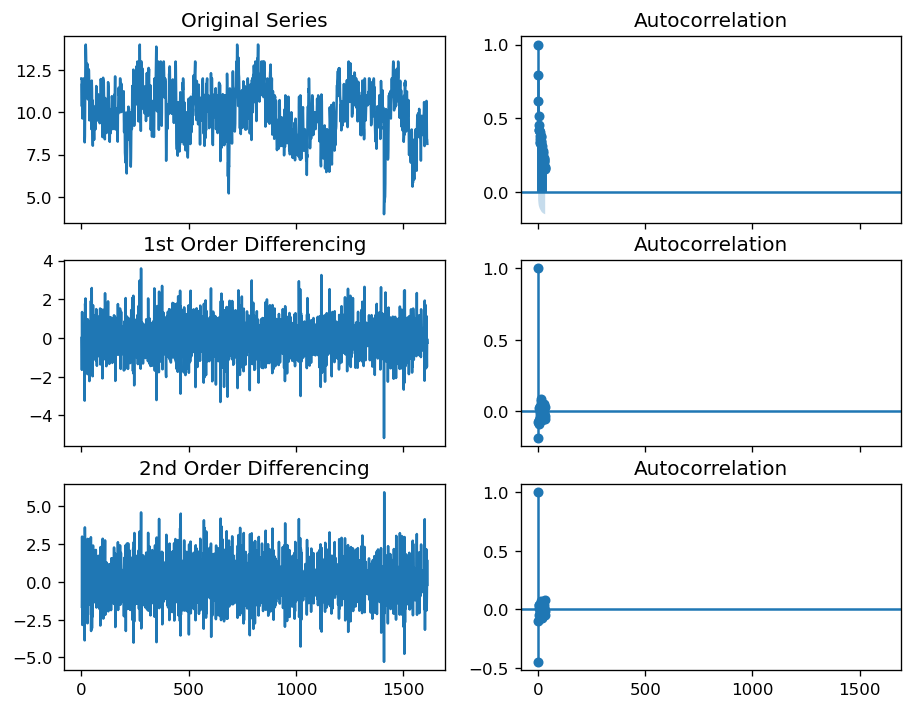

In [57]:
import numpy as np, pandas as pd
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt
plt.rcParams.update({'figure.figsize':(9,7), 'figure.dpi':120})

# Original Series
fig, axes = plt.subplots(3, 2, sharex=True)
axes[0, 0].plot(df['Daily MC Acft']); axes[0, 0].set_title('Original Series')
plot_acf(df['Daily MC Acft'], ax=axes[0, 1])

# 1st Differencing
axes[1, 0].plot(df['Daily MC Acft'].diff()); axes[1, 0].set_title('1st Order Differencing')
plot_acf(df['Daily MC Acft'].diff().dropna(), ax=axes[1, 1])

# 2nd Differencing
axes[2, 0].plot(df['Daily MC Acft'].diff().diff()); axes[2, 0].set_title('2nd Order Differencing')
plot_acf(df['Daily MC Acft'].diff().diff().dropna(), ax=axes[2, 1])

plt.show()

The ADH Test result is 0.000008907 which is less than 0.05. This means we reject the null that the time series possesses a unit root and is non-stationary. In other words, our series pass the test of stationarity and can be used for forecasting.

For this forecasting model, we will use ARIMA or Auto Regressive Integrated Moving Average. ARIMA is a class of models that that ‘explains’ a given time series based on its own past values, that is, its own lags and the lagged forecast errors, so that equation can be used to forecast future values (Prabhakaran, 2021). ARIMA enables to forecast future values using the historical values. ARIMA model is characterized by r terms: p, q, and d.

* p - is the order of the AR term
* q - is the order of the MA term
* d - is the number of differencing required to make the time series stationary (for this series the d is 0, because the series is stationary as proven by the ADH Test)

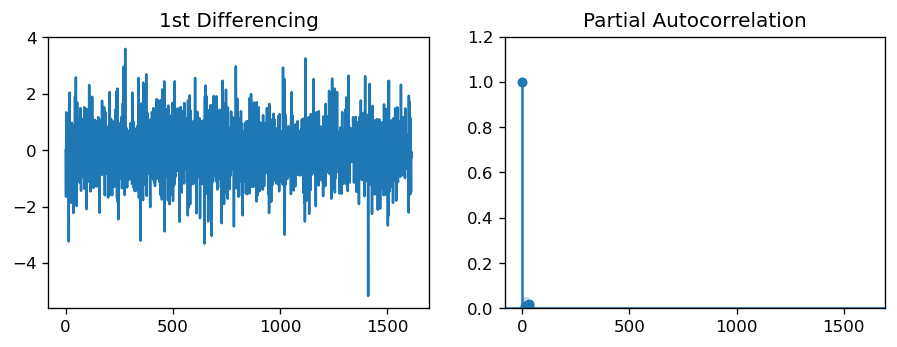

In [66]:
# Find the AR term or p
# PACF plot of 1st differenced series
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.rcParams.update({'figure.figsize':(9,3), 'figure.dpi':120})

fig, axes = plt.subplots(1, 2, sharex=True)
axes[0].plot(df['Daily MC Acft'].diff()); axes[0].set_title('1st Differencing')
axes[1].set(ylim=(0,1.2))
plot_pacf(df['Daily MC Acft'].diff().dropna(), ax=axes[1])

plt.show()

The PACF chart above indicates a p of 1.

Next is to find the MA term for this series.

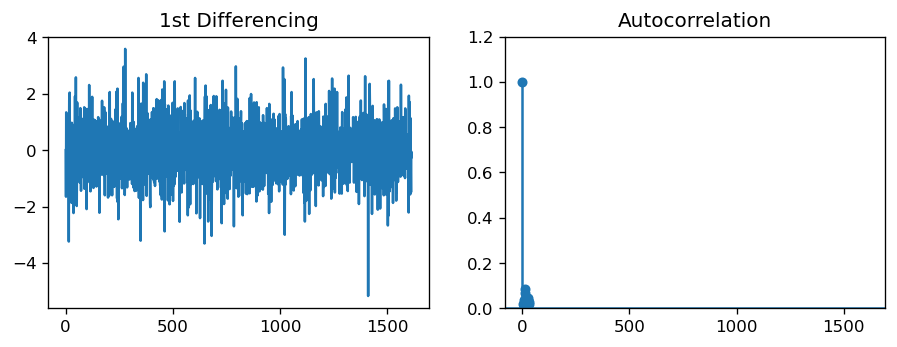

In [65]:
# ACF Plot
fig, axes = plt.subplots(1, 2, sharex=True)
axes[0].plot(df['Daily MC Acft'].diff()); axes[0].set_title('1st Differencing')
axes[1].set(ylim=(0,1.2))
plot_acf(df['Daily MC Acft'].diff().dropna(), ax=axes[1])

plt.show()

We will use a value of 1 as well for the q.

## Building the ARIMA Model

Now that we obtained the p, q, and d values, we can now build the ARIMA model.

In [70]:
from statsmodels.tsa.arima_model import ARIMA

# 1,1,0 ARIMA Model
model = ARIMA(df['Daily MC Acft'], order=(1,1,0))
model_fit = model.fit(disp=0)
print(model_fit.summary())

                             ARIMA Model Results                              
Dep. Variable:        D.Daily MC Acft   No. Observations:                 1613
Model:                 ARIMA(1, 1, 0)   Log Likelihood               -2197.080
Method:                       css-mle   S.D. of innovations              0.945
Date:                Fri, 03 Jun 2022   AIC                           4400.160
Time:                        23:27:21   BIC                           4416.318
Sample:                             1   HQIC                          4406.158
                                                                              
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                    -0.0024      0.022     -0.109      0.913      -0.045       0.040
ar.L1.D.Daily MC Acft    -0.0764      0.025     -3.079      0.002      -0.125      -0.028
        

C:\Users\Rich\anaconda3\lib\site-packages\statsmodels\tsa\arima_model.py:472: FutureWarning: 
statsmodels.tsa.arima_model.ARMA and statsmodels.tsa.arima_model.ARIMA have
been deprecated in favor of statsmodels.tsa.arima.model.ARIMA (note the .
between arima and model) and
statsmodels.tsa.SARIMAX. These will be removed after the 0.12 release.

statsmodels.tsa.arima.model.ARIMA makes use of the statespace framework and
is both well tested and maintained.

To silence this warning and continue using ARMA and ARIMA until they are
removed, use:

import warnings
warnings.filterwarnings('ignore', 'statsmodels.tsa.arima_model.ARMA',
                        FutureWarning)
warnings.filterwarnings('ignore', 'statsmodels.tsa.arima_model.ARIMA',
                        FutureWarning)

  warnings.warn(ARIMA_DEPRECATION_WARN, FutureWarning)


The model summary reveals a lot of information. The table in the middle is the coefficients table where the values under ‘coef’ are the weights of the respective terms.


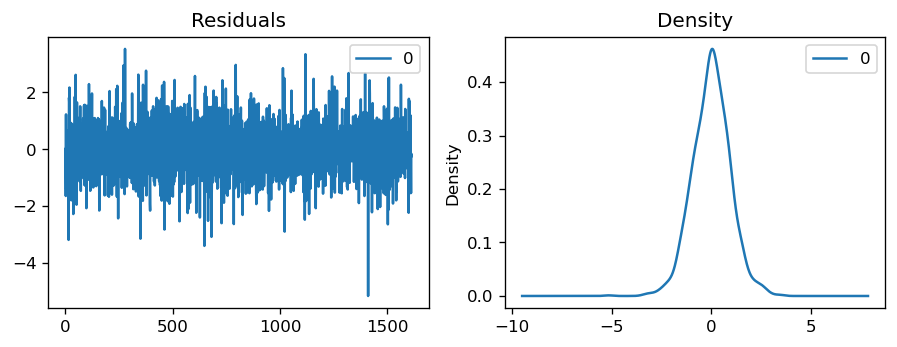

In [71]:
# Plot residual errors
residuals = pd.DataFrame(model_fit.resid)
fig, ax = plt.subplots(1,2)
residuals.plot(title="Residuals", ax=ax[0])
residuals.plot(kind='kde', title='Density', ax=ax[1])
plt.show()

The residual errors seem fine with near zero mean and uniform variance. Let’s plot the actuals against the fitted values using plot_predict().

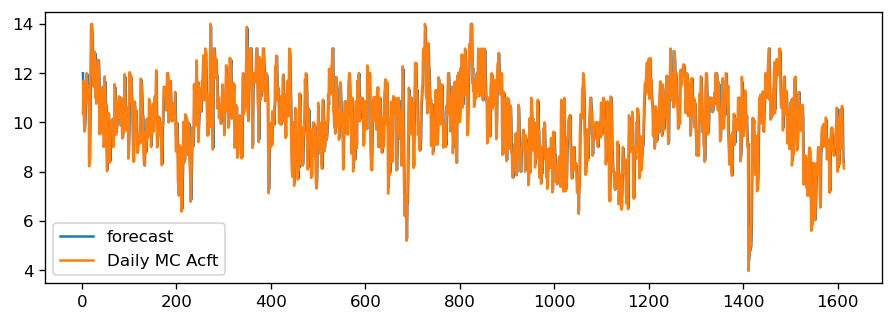

In [74]:
# Actual vs Fitted
model_fit.plot_predict(dynamic=False)
plt.show()

### Out of time validation
In Out-of-Time cross-validation, you take few steps back in time and forecast into the future to as many steps you took back. Then you compare the forecast against the actuals.

To do out-of-time cross-validation, you need to create the training and testing dataset by splitting the time series into 2 contiguous parts in approximately 75:25 ratio or a reasonable proportion based on time frequency of series.

In [76]:
from statsmodels.tsa.stattools import acf

# Create Training and Test
train = df['Daily MC Acft'][:1210]
test = df['Daily MC Acft'][1210:]

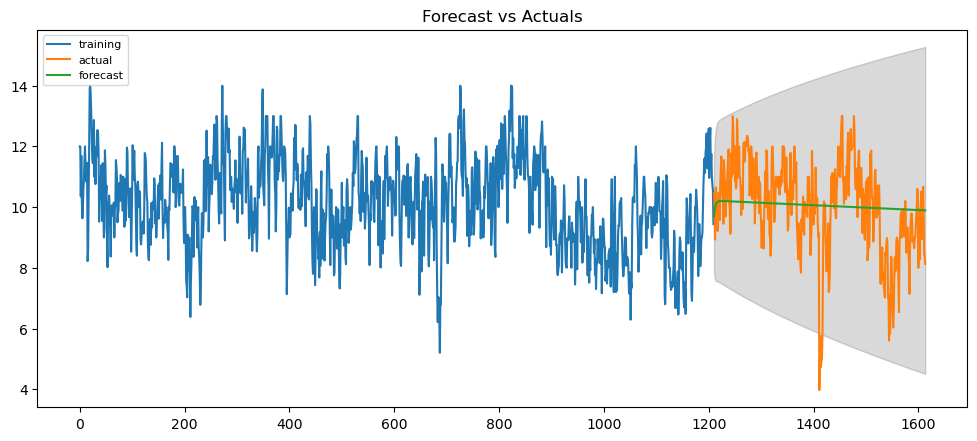

In [86]:
# Build Model
# model = ARIMA(train, order=(1,1,0))  
model = ARIMA(train, order=(1, 1, 1))  
fitted = model.fit(disp=-1)  

# Forecast
fc, se, conf = fitted.forecast(404, alpha=0.05)  # 95% conf

# Make as pandas series
fc_series = pd.Series(fc, index=test.index)
lower_series = pd.Series(conf[:, 0], index=test.index)
upper_series = pd.Series(conf[:, 1], index=test.index)

# Plot
plt.figure(figsize=(12,5), dpi=100)
plt.plot(train, label='training')
plt.plot(test, label='actual')
plt.plot(fc_series, label='forecast')
plt.fill_between(lower_series.index, lower_series, upper_series, 
                 color='k', alpha=.15)
plt.title('Forecast vs Actuals')
plt.legend(loc='upper left', fontsize=8)
plt.show()

From the chart, the ARIMA(1,1,1) model seems to give a directionally correct forecast. And the actual observed values lie within the 95% confidence band. That seems fine.

But each of the predicted forecasts is consistently below the actuals. That means, by adding a small constant to our forecast, the accuracy will certainly improve. So, there is definitely scope for improvement.

In [87]:
# Accuracy metrics
def forecast_accuracy(forecast, actual):
    mape = np.mean(np.abs(forecast - actual)/np.abs(actual))  # MAPE
    me = np.mean(forecast - actual)             # ME
    mae = np.mean(np.abs(forecast - actual))    # MAE
    mpe = np.mean((forecast - actual)/actual)   # MPE
    rmse = np.mean((forecast - actual)**2)**.5  # RMSE
    corr = np.corrcoef(forecast, actual)[0,1]   # corr
    mins = np.amin(np.hstack([forecast[:,None], 
                              actual[:,None]]), axis=1)
    maxs = np.amax(np.hstack([forecast[:,None], 
                              actual[:,None]]), axis=1)
    minmax = 1 - np.mean(mins/maxs)             # minmax
    acf1 = acf(fc-test)[1]                      # ACF1
    return({'mape':mape, 'me':me, 'mae': mae, 
            'mpe': mpe, 'rmse':rmse, 'acf1':acf1, 
            'corr':corr, 'minmax':minmax})

forecast_accuracy(fc, test.values)

#> {'mape': 0.02250131357314834,
#>  'me': 3.230783108990054,
#>  'mae': 4.548322194530069,
#>  'mpe': 0.016421001932706705,
#>  'rmse': 6.373238534601827,
#>  'acf1': 0.5105506325288692,
#>  'corr': 0.9674576513924394,
#>  'minmax': 0.02163154777672227}

C:\Users\Rich\anaconda3\lib\site-packages\statsmodels\tsa\stattools.py:657: FutureWarning: The default number of lags is changing from 40 tomin(int(10 * np.log10(nobs)), nobs - 1) after 0.12is released. Set the number of lags to an integer to  silence this warning.
  warnings.warn(
C:\Users\Rich\anaconda3\lib\site-packages\statsmodels\tsa\stattools.py:667: FutureWarning: fft=True will become the default after the release of the 0.12 release of statsmodels. To suppress this warning, explicitly set fft=False.
  warnings.warn(


{'mape': 0.1280585437528322,
 'me': 0.012776075530291725,
 'mae': 1.1390842714761387,
 'mpe': 0.03057049218441324,
 'rmse': 1.4870103486466761,
 'acf1': 0.8064857833577558,
 'corr': 0.3971358088930403,
 'minmax': 0.1063427049079152}

In [89]:
from statsmodels.tsa.arima_model import ARIMA
import pmdarima as pm

model = pm.auto_arima(df['Daily MC Acft'], start_p=1, start_q=1,
                      test='adf',       # use adftest to find optimal 'd'
                      max_p=3, max_q=3, # maximum p and q
                      m=1,              # frequency of series
                      d=None,           # let model determine 'd'
                      seasonal=False,   # No Seasonality
                      start_P=0, 
                      D=0, 
                      trace=True,
                      error_action='ignore',  
                      suppress_warnings=True, 
                      stepwise=True)

print(model.summary())

Performing stepwise search to minimize aic
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=4398.434, Time=0.27 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=12088.218, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.10 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=10039.808, Time=0.06 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=inf, Time=0.56 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=4279.400, Time=0.28 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=8536.665, Time=0.22 sec
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=4199.435, Time=0.23 sec
 ARIMA(3,0,2)(0,0,0)[0]             : AIC=4211.287, Time=0.87 sec
 ARIMA(2,0,3)(0,0,0)[0]             : AIC=4200.722, Time=0.65 sec
 ARIMA(1,0,3)(0,0,0)[0]             : AIC=4224.213, Time=0.37 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=4199.857, Time=0.50 sec
 ARIMA(3,0,3)(0,0,0)[0]             : AIC=inf, Time=1.15 sec
 ARIMA(2,0,2)(0,0,0)[0] intercept   : AIC=4180.853, Time=1.36 sec
 ARIMA(1,0,2)(0,0,0)[0] intercept   : AIC=4215

C:\Users\Rich\anaconda3\lib\site-packages\statsmodels\graphics\gofplots.py:993: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "bo" (-> marker='o'). The keyword argument will take precedence.
  ax.plot(x, y, fmt, **plot_style)


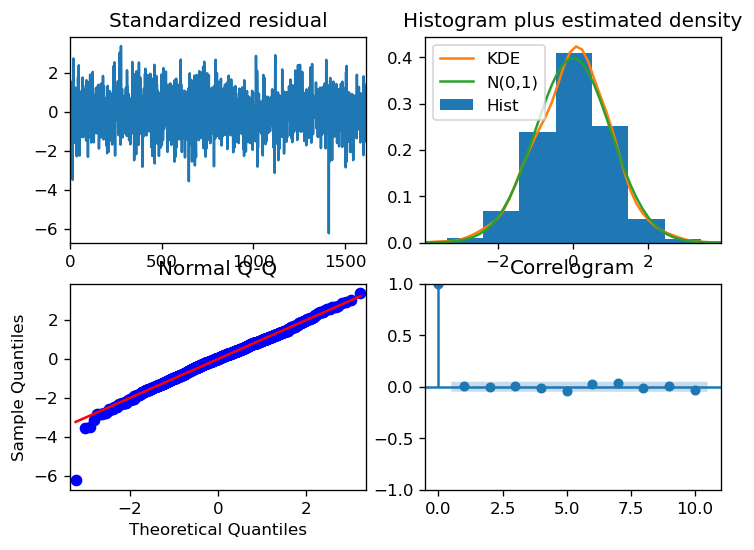

In [90]:
# Residual plots
model.plot_diagnostics(figsize=(7,5))
plt.show()

So how to interpret the plot diagnostics?

Top left: The residual errors seem to fluctuate around a mean of zero and have a uniform variance.

Top Right: The density plot suggest normal distribution with mean zero.

Bottom left: All the dots should fall perfectly in line with the red line. Any significant deviations would imply the distribution is skewed.

Bottom Right: The Correlogram, aka, ACF plot shows the residual errors are not autocorrelated. Any autocorrelation would imply that there is some pattern in the residual errors which are not explained in the model. So you will need to look for more X’s (predictors) to the model.

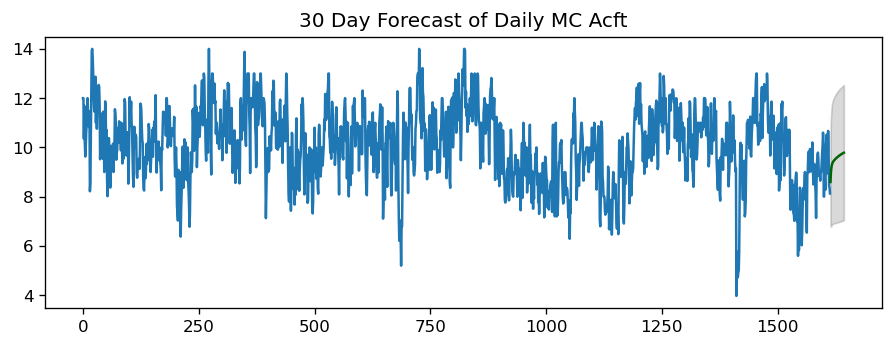

In [99]:
# Forecast
n_periods = 30
fc, confint = model.predict(n_periods=n_periods, return_conf_int=True)
index_of_fc = np.arange(len(df['Daily MC Acft']), len(df['Daily MC Acft'])+n_periods)

# make series for plotting purpose
fc_series = pd.Series(fc, index=index_of_fc)
lower_series = pd.Series(confint[:, 0], index=index_of_fc)
upper_series = pd.Series(confint[:, 1], index=index_of_fc)

# Plot
plt.plot(df['Daily MC Acft'])
plt.plot(fc_series, color='darkgreen')
plt.fill_between(lower_series.index, 
                 lower_series, 
                 upper_series, 
                 color='k', alpha=.15)

plt.title("30 Day Forecast of Daily MC Acft")
plt.show()